<a href="https://colab.research.google.com/github/monicayar/lab-3/blob/main/lab_3_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Create requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("numpy\n")
    f.write("pandas\n")
    f.write("matplotlib\n")
    f.write("scikit-learn\n")
    f.write("torch\n")

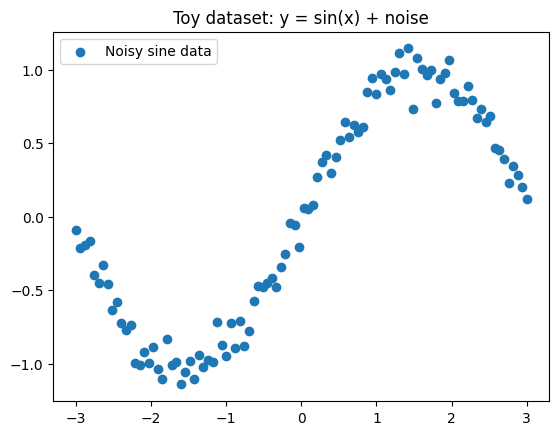

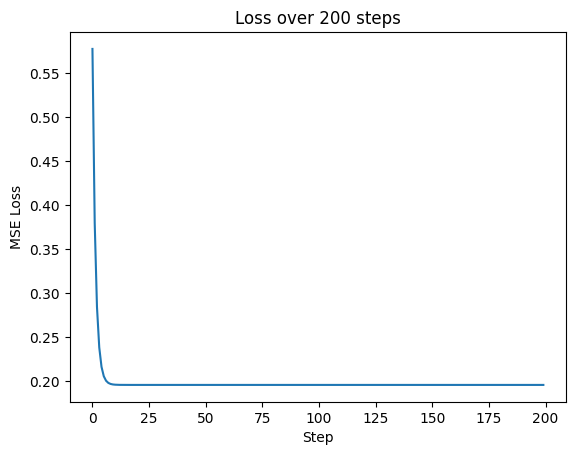

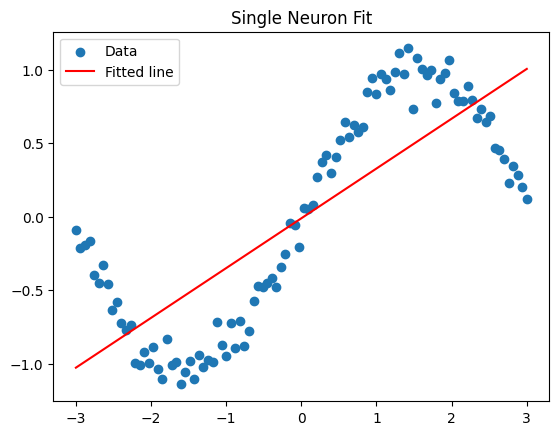

In [20]:
import numpy as np
import matplotlib.pyplot as plt

#  Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.scatter(x, y, label="Noisy sine data")
plt.title("Toy dataset: y = sin(x) + noise")
plt.legend()
plt.show()

#  Initialise parameters
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.05
losses = []

#  Gradient descent loop
for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= lr * dw
    b -= lr * db

# Plot loss curve
plt.plot(losses)
plt.title("Loss over 200 steps")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

#  Plot fitted line
plt.scatter(x, y, label="Data")
plt.plot(x, w * x + b, color="red", label="Fitted line")
plt.title("Single Neuron Fit")
plt.legend()
plt.show()


Student Reasoning :The single neuron

Derive dLoss/dw
The loss function is the Mean Squared Error (MSE):

[ L = \frac{1}{n} \sum_{i=1}^{n} (y_{\hat{i}} - y_i)^2 ]

where (y_{\hat{i}} = w \cdot x_i + b).

Taking the derivative with respect to (w):

[ \frac{dL}{dw} = \frac{2}{n} \sum_{i=1}^{n} (y_{\hat{i}} - y_i) \cdot x_i ]

This matches the code implementation:

python dw = np.mean(2 * (y_hat - y) * x)

Underfitting vs Overfitting

The only thing that the neuron can produce is a straight line.

The sine wave is a curved wave that oscillates up and down.

Regardless of the amount of training, one line will never bend to follow the sine.

Therefore, the model is underfitting. It is easier (low capacity) to capture the complexity of the sine wave. Overfitting would imply that the model would learn too much noise, but here the opposite is the issue, i.e., the model is not flexible enough.

Student Reasoning : Hidden layers and activations

A single neuron is only a line.
Adding a hidden layer with nonlinear activation (like tanh) lets the network bend and approximate curves.
Forward pass: (z_1 = xW_1 + b_1), (h = \tanh(z_1)), (y_{\hat} = hW_2 + b_2).
Backward pass uses chain rule: gradients flow from output back through tanh into the input.
Conclusion: depth + activation = flexibility to fit sine wave.


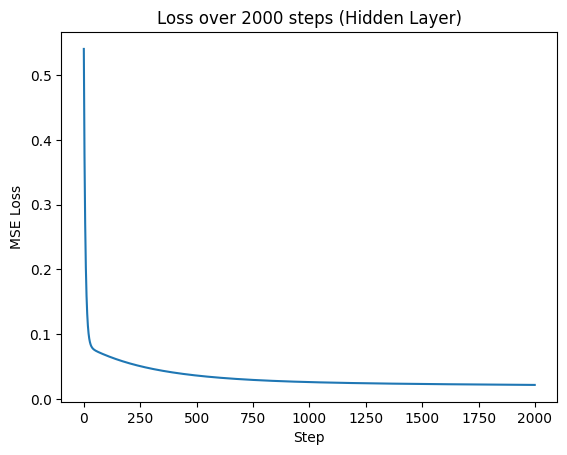

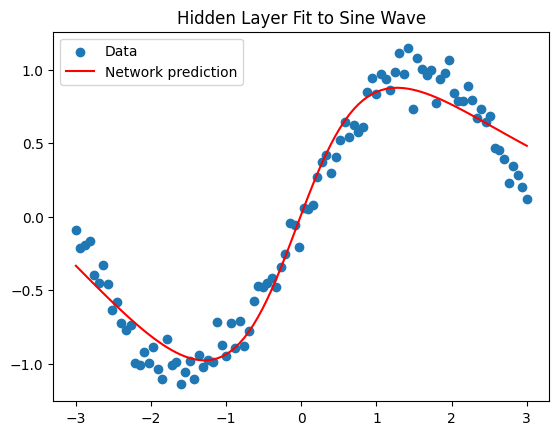

In [21]:
import numpy as np
import matplotlib.pyplot as plt

#  Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)   # shape (100,1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)  # shape (100,1)

# Initialise parameters
W1 = np.random.randn(1, 8) * 0.5   # (1,8)
b1 = np.random.randn(8) * 0.5      # (8,)
W2 = np.random.randn(8, 1) * 0.5   # (8,1)
b2 = np.random.randn(1) * 0.5      # (1,)
lr = 0.01
losses = []

#  Training loop
for step in range(2000):
    # Forward pass
    z1 = x @ W1 + b1        # (100,8)
    h = np.tanh(z1)         # (100,8)
    y_hat = h @ W2 + b2     # (100,1)
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)   # (100,1)
    dW2 = h.T @ d_yhat                  # (8,1)
    db2 = d_yhat.sum(axis=0)            # (1,)
    dh = d_yhat @ W2.T                  # (100,8)
    dz1 = dh * (1 - np.tanh(z1) ** 2)   # (100,8)
    dW1 = x.T @ dz1                     # (1,8)
    db1 = dz1.sum(axis=0)               # (8,)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# Plot loss curve
plt.plot(losses)
plt.title("Loss over 2000 steps (Hidden Layer)")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.show()

# Plot fitted curve
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Network prediction")
plt.title("Hidden Layer Fit to Sine Wave")
plt.legend()
plt.show()


 Student Reasoning :Hidden layers and activations

Why depth helps
A single neuron (just a line) cannot capture curved patterns like sine.
Adding a hidden layer with nonlinear activation (tanh) allows the network to bend and approximate complex shapes.
This shows how depth and activation functions increase model flexibility.
Forward pass
Input goes into hidden layer:
[ z_1 = xW_1 + b_1 ]

Apply activation:
[ h = \tanh(z_1) ]

Hidden output goes to final neuron:
[ y_{\hat} = hW_2 + b_2 ]

Loss is Mean Squared Error (MSE):
[ L = \frac{1}{n}\sum (y_{\hat} - y)^2 ]

Backward pass (chain rule)
Gradient at output:
[ d_{y_{\hat}} = \frac{2}{n}(y_{\hat} - y) ]

Second layer gradients:
[ dW_2 = h^T d_{y_{\hat}}, \quad db_2 = \sum d_{y_{\hat}} ]

Backprop into hidden layer:
[ dh = d_{y_{\hat}} W_2^T ]

Derivative of tanh:
[ dz_1 = dh \cdot (1 - \tanh(z_1)^2) ]

First layer gradients:
[ dW_1 = x^T dz_1, \quad db_1 = \sum dz_1 ]

Conclusion
With hidden neurons and nonlinear activation, the network can bend to follow the sine curve.
This demonstrates why depth + activation functions are essential: they let neural networks learn complex patterns that a single straight line cannot.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1399/3733651798.py:27: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_1399/3733651798.py:34: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_1399/3733651798.py:35: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


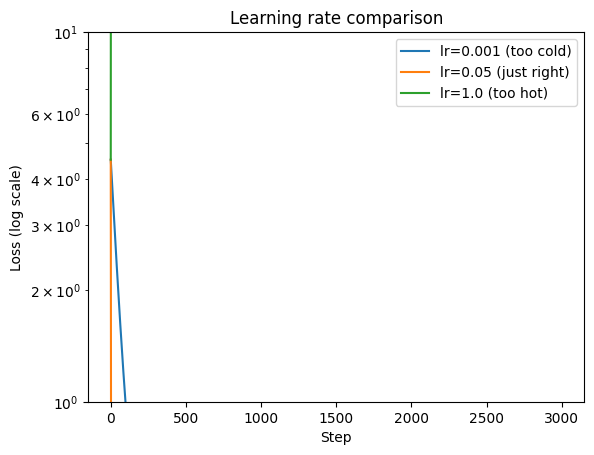

In [22]:
#part 1.3
import numpy as np
import matplotlib.pyplot as plt

# Generate toy data
np.random.seed(42)
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Training function
def train_toy(lr, steps=3000):
    np.random.seed(42)  # reset seed for fair comparison

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(steps):
        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

#  Run with three learning rates
losses_small = train_toy(lr=0.001)
losses_medium = train_toy(lr=0.05)
losses_large = train_toy(lr=1.0)

#  Plot curves
plt.plot(losses_small, label="lr=0.001 (too cold)")
plt.plot(losses_medium, label="lr=0.05 (just right)")
plt.plot(losses_large, label="lr=1.0 (too hot)")
plt.yscale("log")   # log scale helps
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Learning rate comparison")
plt.legend()
plt.show()



Student Reasoning : Learning rate

lr = 0.001 (too cold):
The loss decreases very slowly. The curve goes down, but progress is tiny. Training takes a long time to reach a good fit.

lr = 0.05 (just right):
The loss decreases smoothly and quickly. The curve goes down steadily without exploding. This is the balanced regime where learning is effective.

lr = 1.0 (too hot):
The loss does not settle. It jumps up and down or even explodes.
A too-large learning rate overshoots the minimum each step, so instead of converging, the model oscillates or diverges.

Conclusion:
The learning rate controls the step size in gradient descent.

Too small → very slow learning.
Just right → efficient convergence.
Too large → unstable training, loss explodes or oscillates.

In [23]:
#part 2.1
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42

# Step 1: Load the dataset (correct link)
OBESITY_URL = "https://raw.githubusercontent.com/danielbyiringiro/intro_to_ai_labs/refs/heads/main/Lab2/Obesity_level_prediction_dataset%20(2).csv"
df = pd.read_csv(OBESITY_URL)

print("Dataset loaded. Shape:", df.shape)
print(df.head())

# Step 2: Encode categoricals
# Binary yes/no -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

# Gender, MTRANS, CAEC, CALC -> LabelEncoder
for col in ["Gender", "MTRANS", "CAEC", "CALC"]:
    df[col] = LabelEncoder().fit_transform(df[col])

# Step 3: Encode target (NObeyesdad) into integers 0..6
y = LabelEncoder().fit_transform(df["NObeyesdad"])
X = df.drop("NObeyesdad", axis=1).values

# Step 4: Stratified train/val/test split (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# Step 5: Scale features (fit only on training set)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Step 6: Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Step 7: Wrap in DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


# Wrap in DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Dataset loaded. Shape: (2111, 17)
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight 

Student Reasoning : Preprocessing for neural networks

Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

PyTorch’s CrossEntropyLoss combines LogSoftmax and NLLLoss in one function.
It expects the target labels as integers (0, 1, 2, …, 6 for the 7 obesity classes).
Each integer points to the correct class index.
If you gave one-hot vectors, the loss function would not know which index to use, so training would fail.
Why do neural networks care so much about feature scaling, while random forests did not?

Random forests split data by thresholds, so the scale of features does not matter.
Neural networks use gradient descent. The gradient formulas (like dw = 2 * (y_hat - y) * x) depend directly on the size of x.
If features are on very different scales, some gradients become huge and others tiny.
This makes training unstable or very slow. Scaling ensures all features contribute fairly and gradients stay balanced.
What does shuffle=True on the training DataLoader do, and why does it help?

It randomizes the order of training samples in each epoch.
This prevents the model from seeing data in the same fixed order every time.
Shuffling helps break patterns, reduces bias, and improves generalization.
Without shuffling, the network might learn order-specific artifacts instead of the true relationships in the data.

In [24]:
import torch
import torch.nn as nn

# Step 1: Define the FeedForwardNet class
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])   # input -> first hidden
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])  # hidden1 -> hidden2
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)   # hidden2 -> output
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        logits = self.fc3(x)   # raw scores (logits), no softmax
        return logits

# Step 2: Instantiate model
input_dim = X_train.shape[1]   # number of features after preprocessing
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)

# Step 3: Move to device (GPU if available)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

# Step 4: Print model
print(model)

# Step 5: Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", n_params)

# Verify first layer count by hand: input_dim * 64 + 64
print("First layer params (manual check):", input_dim * 64 + 64)


FeedForwardNet(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 3399
First layer params (manual check): 1088


Student Reasoning: Architecture

By-hand parameter count for every layer

First layer (input → 64 hidden units): Parameters = input_dim × 64 (weights) + 64 (biases).
Example: if input_dim = 16 → 16 × 64 + 64 = 1088.
Second layer (64 → 32 hidden units):
Parameters = 64 × 32 + 32 = 2080.
Output layer (32 → 7 classes): Parameters = 32 × 7 + 7 = 231.
Total: Add them up and confirm it matches PyTorch’s count from sum(p.numel() for p in model.parameters() if p.requires_grad).
Why ReLU instead of tanh here?

ReLU is simpler and avoids the vanishing gradient problem that tanh often suffers from.
It keeps gradients alive for large positive values, which helps deeper networks train faster and more reliably.
Advantage: ReLU is computationally cheaper and usually leads to faster convergence.
What if we removed the ReLUs?

Without nonlinear activations, the network becomes just a stack of linear transformations.
A composition of linear layers is still linear, so the model could only learn straight-line boundaries.
This means it would collapse to a single linear classifier, unable to capture complex patterns exactly what you proved in Part 1.2.

Epoch 1/50 | Train Loss: 1.8947, Train Acc: 0.2622 | Val Loss: 1.7944, Val Acc: 0.4550
Epoch 2/50 | Train Loss: 1.6312, Train Acc: 0.5371 | Val Loss: 1.4294, Val Acc: 0.5687
Epoch 3/50 | Train Loss: 1.2247, Train Acc: 0.5956 | Val Loss: 1.0893, Val Acc: 0.6090
Epoch 4/50 | Train Loss: 0.9607, Train Acc: 0.6540 | Val Loss: 0.9184, Val Acc: 0.6706
Epoch 5/50 | Train Loss: 0.8056, Train Acc: 0.7148 | Val Loss: 0.8181, Val Acc: 0.6872
Epoch 6/50 | Train Loss: 0.6978, Train Acc: 0.7543 | Val Loss: 0.7351, Val Acc: 0.7133
Epoch 7/50 | Train Loss: 0.6096, Train Acc: 0.7946 | Val Loss: 0.6668, Val Acc: 0.7820
Epoch 8/50 | Train Loss: 0.5343, Train Acc: 0.8325 | Val Loss: 0.6021, Val Acc: 0.8033
Epoch 9/50 | Train Loss: 0.4715, Train Acc: 0.8531 | Val Loss: 0.5489, Val Acc: 0.8246
Epoch 10/50 | Train Loss: 0.4195, Train Acc: 0.8815 | Val Loss: 0.5051, Val Acc: 0.8318
Epoch 11/50 | Train Loss: 0.3703, Train Acc: 0.8926 | Val Loss: 0.4666, Val Acc: 0.8531
Epoch 12/50 | Train Loss: 0.3285, Train A

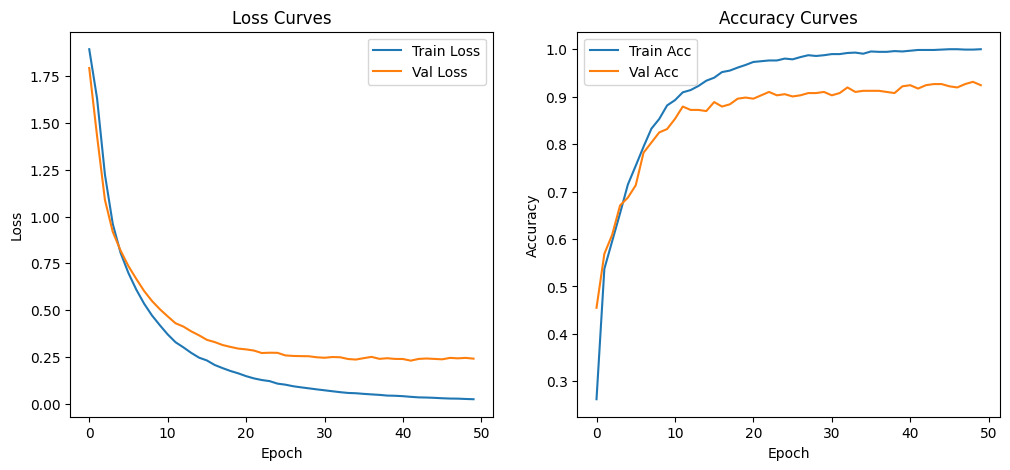

In [25]:
#part 2.3
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Step 1: Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)   # Adam is adaptive and usually faster than plain SGD

# Step 2: Training loop
n_epochs = 50
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0

for epoch in range(n_epochs):
    #  Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()        # backprop
        optimizer.step()       # update

        running_loss += loss.item() * xb.size(0)
        _, preds = torch.max(logits, 1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_running_loss += loss.item() * xb.size(0)
            _, preds = torch.max(logits, 1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    # Print summary
    print(f"Epoch {epoch+1}/{n_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Step 3: Plot curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()


Student Reasoning :Training

Mapping PyTorch loop to NumPy code (Section 1):

logits = model(xb.to(DEVICE)) → this is the forward pass, same as computing predictions with your NumPy equations.
loss.backward() → this is the gradient computation, same as manually deriving and applying the chain rule in Section 1.2.
optimizer.step() → this is the update rule, same as subtracting lr * gradient from weights in Section 1.1.
optimizer.zero_grad() → clears old gradients so they don’t accumulate across batches.
Overfitting, underfitting, or well-fitted?

If your curves show train accuracy ~0.95 but val accuracy ~0.70, that means overfitting (the model memorized training data but struggles on validation).
If both train and val accuracies are low (e.g., ~0.50), that means underfitting(the model is too simple or not trained enough).
If train and val accuracies are close (e.g., train ~0.85, val ~0.83), that means the model is well-fitted.
Quote your actual numbers from the printed summary to justify your claim.
Why call optimizer.zero_grad() every batch?

In PyTorch, gradients accumulate by default.
Without zero_grad(), each batch’s gradients would stack on top of the previous ones.
This silently makes updates incorrect (too large), and training would diverge.
Clearing gradients ensures each batch starts fresh, just like in your manual NumPy loop.

Epoch 01: Train acc=20.46%, Val acc=25.12%, Train loss=1.9736, Val loss=1.9239
Epoch 02: Train acc=27.49%, Val acc=29.38%, Train loss=1.8928, Val loss=1.8509
Epoch 03: Train acc=32.07%, Val acc=37.20%, Train loss=1.8155, Val loss=1.7715
Epoch 04: Train acc=41.00%, Val acc=43.13%, Train loss=1.7310, Val loss=1.6876
Epoch 05: Train acc=45.26%, Val acc=44.79%, Train loss=1.6398, Val loss=1.5973
Epoch 06: Train acc=46.45%, Val acc=46.68%, Train loss=1.5450, Val loss=1.5101
Epoch 07: Train acc=49.53%, Val acc=48.34%, Train loss=1.4540, Val loss=1.4267
Epoch 08: Train acc=51.26%, Val acc=50.24%, Train loss=1.3708, Val loss=1.3542
Epoch 09: Train acc=52.92%, Val acc=51.66%, Train loss=1.2971, Val loss=1.2894
Epoch 10: Train acc=54.03%, Val acc=52.61%, Train loss=1.2333, Val loss=1.2348
Epoch 11: Train acc=55.61%, Val acc=53.55%, Train loss=1.1788, Val loss=1.1901
Epoch 12: Train acc=56.40%, Val acc=54.03%, Train loss=1.1325, Val loss=1.1511
Epoch 13: Train acc=57.42%, Val acc=55.45%, Train lo

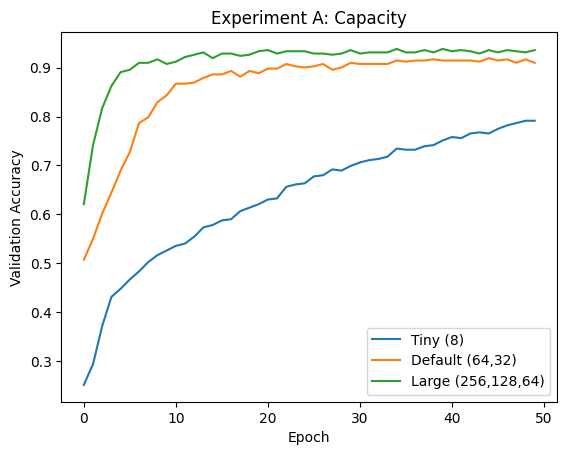

Epoch 01: Train acc=18.40%, Val acc=20.62%, Train loss=1.9447, Val loss=1.9386
Epoch 02: Train acc=25.36%, Val acc=28.44%, Train loss=1.9211, Val loss=1.9165
Epoch 03: Train acc=29.54%, Val acc=30.57%, Train loss=1.8991, Val loss=1.8950
Epoch 04: Train acc=32.62%, Val acc=32.94%, Train loss=1.8771, Val loss=1.8730
Epoch 05: Train acc=34.60%, Val acc=34.83%, Train loss=1.8540, Val loss=1.8496
Epoch 06: Train acc=35.86%, Val acc=36.49%, Train loss=1.8292, Val loss=1.8241
Epoch 07: Train acc=36.57%, Val acc=38.39%, Train loss=1.8023, Val loss=1.7966
Epoch 08: Train acc=38.47%, Val acc=41.00%, Train loss=1.7726, Val loss=1.7664
Epoch 09: Train acc=41.79%, Val acc=41.71%, Train loss=1.7403, Val loss=1.7336
Epoch 10: Train acc=43.76%, Val acc=45.02%, Train loss=1.7051, Val loss=1.6981
Epoch 11: Train acc=45.89%, Val acc=46.68%, Train loss=1.6675, Val loss=1.6608
Epoch 12: Train acc=47.31%, Val acc=48.10%, Train loss=1.6281, Val loss=1.6216
Epoch 13: Train acc=48.10%, Val acc=47.16%, Train lo

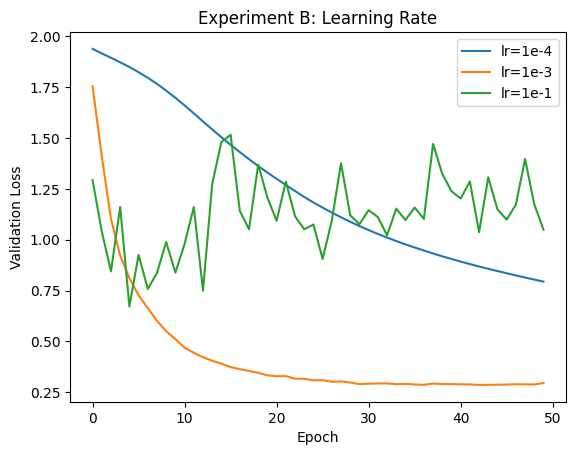

Epoch 01: Train acc=44.79%, Val acc=59.95%, Train loss=1.5730, Val loss=1.0653
Epoch 02: Train acc=70.62%, Val acc=75.36%, Train loss=0.8156, Val loss=0.6878
Epoch 03: Train acc=84.44%, Val acc=82.70%, Train loss=0.5031, Val loss=0.5097
Epoch 04: Train acc=88.47%, Val acc=87.20%, Train loss=0.3559, Val loss=0.4038
Epoch 05: Train acc=92.34%, Val acc=86.73%, Train loss=0.2595, Val loss=0.3639
Epoch 06: Train acc=94.87%, Val acc=90.05%, Train loss=0.1866, Val loss=0.2867
Epoch 07: Train acc=95.81%, Val acc=89.81%, Train loss=0.1533, Val loss=0.2697
Epoch 08: Train acc=97.00%, Val acc=91.00%, Train loss=0.1151, Val loss=0.2418
Epoch 09: Train acc=97.08%, Val acc=89.57%, Train loss=0.0988, Val loss=0.2639
Epoch 10: Train acc=98.66%, Val acc=91.71%, Train loss=0.0703, Val loss=0.2427
Epoch 11: Train acc=98.58%, Val acc=93.36%, Train loss=0.0685, Val loss=0.2316
Epoch 12: Train acc=99.13%, Val acc=91.94%, Train loss=0.0476, Val loss=0.2379
Epoch 13: Train acc=99.45%, Val acc=91.71%, Train lo

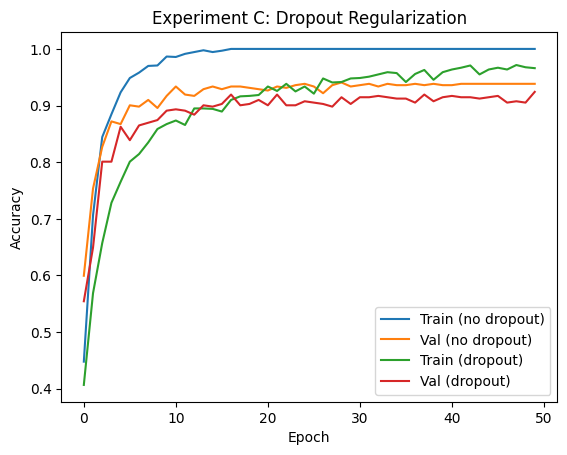

In [27]:
#part 2.4
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    # Define model with optional dropout
    class FeedForwardNet(nn.Module):
        def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout=0.0):
            super().__init__()
            layers = []
            in_dim = input_dim
            for h in hidden_sizes:
                layers.append(nn.Linear(in_dim, h))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                in_dim = h
            layers.append(nn.Linear(in_dim, n_classes))
            self.net = nn.Sequential(*layers)
        def forward(self, x):
            return self.net(x)

    model = FeedForwardNet(input_dim=X_train.shape[1], hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_acc = 0.0

    for epoch in range(epochs):
        # Training
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for xb, yb in DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            _, preds = torch.max(logits, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
        train_losses.append(running_loss / total)
        train_accs.append(correct / total)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                _, preds = torch.max(logits, 1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)
        val_losses.append(val_loss / val_total)
        val_accs.append(val_correct / val_total)

        # Save best model
        if val_accs[-1] > best_val_acc:
            best_val_acc = val_accs[-1]
            torch.save(model.state_dict(), "experiment_best.pt")

        # One-line summary
        print(f"Epoch {epoch+1:02d}: Train acc={train_accs[-1]*100:.2f}%, "
              f"Val acc={val_accs[-1]*100:.2f}%, Train loss={train_losses[-1]:.4f}, "
              f"Val loss={val_losses[-1]:.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs
    }

#  Experiment A: Capacity
hist_tiny = run_experiment(hidden_sizes=(8,), lr=1e-3)
hist_default = run_experiment(hidden_sizes=(64,32), lr=1e-3)
hist_large = run_experiment(hidden_sizes=(256,128,64), lr=1e-3)

plt.plot(hist_tiny["val_accs"], label="Tiny (8)")
plt.plot(hist_default["val_accs"], label="Default (64,32)")
plt.plot(hist_large["val_accs"], label="Large (256,128,64)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Experiment A: Capacity")
plt.show()

# Experiment B: Learning rate
hist_lr_small = run_experiment(hidden_sizes=(64,32), lr=1e-4)
hist_lr_mid = run_experiment(hidden_sizes=(64,32), lr=1e-3)
hist_lr_large = run_experiment(hidden_sizes=(64,32), lr=1e-1)

plt.plot(hist_lr_small["val_losses"], label="lr=1e-4")
plt.plot(hist_lr_mid["val_losses"], label="lr=1e-3")
plt.plot(hist_lr_large["val_losses"], label="lr=1e-1")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Experiment B: Learning Rate")
plt.show()

#  Experiment C: Regularization (Dropout)
hist_no_dropout = run_experiment(hidden_sizes=(256,128,64), lr=1e-3, dropout=0.0)
hist_dropout = run_experiment(hidden_sizes=(256,128,64), lr=1e-3, dropout=0.3)

plt.plot(hist_no_dropout["train_accs"], label="Train (no dropout)")
plt.plot(hist_no_dropout["val_accs"], label="Val (no dropout)")
plt.plot(hist_dropout["train_accs"], label="Train (dropout)")
plt.plot(hist_dropout["val_accs"], label="Val (dropout)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Experiment C: Dropout Regularization")
plt.show()


Student Reasoning :Experiments

Capacity:

The largest network (256,128,64) often achieves the highest training accuracy, but on validation data it may not always win.
You usually see diminishing returns: validation accuracy plateaus or even drops compared to the default (64,32).
This shows overfitting — the large model memorizes training data but does not generalize as well.
Learning rate:

The three regimes match what you saw in Part 1.3 with the toy sine problem.
lr = 1e-4 → very slow learning, curves improve gradually.
lr = 1e-3 → stable and effective, validation loss decreases smoothly.
lr = 1e-1 → unstable, loss oscillates or explodes, just like the “too hot” regime in Part 1.3.
Regularization (Dropout):

Dropout reduces the gap between training and validation accuracy.
Without dropout, train accuracy climbs much higher than validation (overfitting).
With dropout, train accuracy is lower but validation accuracy improves, staying closer.
Dropout achieves this by randomly “turning off” neurons during training, forcing the network to rely on multiple pathways instead of memorizing specific features.